In [123]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

class NNclass:
  def GELU(self, x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) *(x + 0.044715 * x**3)))
  def dGELU(self, x):
    tanh_term = np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3))
    left = 0.5*(1+tanh_term)
    right = (0.5*x*(1-tanh_term**2)*np.sqrt(2/np.pi)*(1+3*0.044715*x**2))
    return left + right
  def predict(self,Xpredict):
    factivlayers = [Xpredict]
    fneuronlayers = []
    for i in range(len(self.nnarchitecture)-2):
      fneuronlayers.append(np.dot(factivlayers[i],self.weights[i]) + self.bias[i])
      factivlayers.append(self.GELU(fneuronlayers[-1]))
    fneuronlayers.append(np.dot(factivlayers[-1],self.weights[-1]) + self.bias[-1])
    expmatrix = np.exp(fneuronlayers[-1]-np.max(fneuronlayers[-1],axis=1,keepdims=True))
    row_sums = np.sum(expmatrix, axis=1)[:, None]
    fYpredicted = expmatrix / row_sums
    return fYpredicted,fneuronlayers,factivlayers
  def targetpredict(self,Xpredict):
    ymat = self.predict(Xpredict)[0]
    idx = np.argmax(ymat,axis=1)
    return self.classes[idx]
  def accuracy(self,Ypredict,Ytest):
    return np.mean(Ypredict == Ytest)
  def precision(self,Ypredict,Ytest):
    precdict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FP = np.sum(binYpredict) - TP
      precdict[f"Precision class {self.classes[i]}"] = float(TP/(TP+FP))
    return precdict
  def recall(self,Ypredict,Ytest):
    recdict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FN = np.sum(binY) - TP
      recdict[f"Recall class {self.classes[i]}"] = float(TP/(TP+FN))
    return recdict
  def f1score(self,Ypredict,Ytest):
    f1dict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FP = np.sum(binYpredict) - TP
      FN = np.sum(binY) - TP
      precision = TP/(TP+FP)
      recall = TP/(TP+FN)
      f1dict[f"F1 Score class {self.classes[i]}"] = float(2*precision*recall/(precision+recall))
    return f1dict
  def confusionmatrix(self,Ypredict,Ytest):
    cmatrix = np.zeros((len(self.classes), len(self.classes)), dtype=int)
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      for j in range(len(self.classes)):
        binYpredict = (Ypredict == self.classes[j]).astype(int)
        cmatrix[i][j] = np.sum(binY*binYpredict)
    sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues',xticklabels=self.classes,yticklabels=self.classes)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predcited")
    plt.show()
    return cmatrix
  def fit(self,Xtrain,Ytrain,lrate=0.05,epoch = 10000,batchsize = 32):
    #init
    self.classes = np.unique(Ytrain)
    hidencount = np.random.randint((len(self.classes)+Xtrain.shape[1])//2, Xtrain.shape[1])
    rng = np.random.default_rng()
    #random architecture
    #self.nnarchitecture = np.concatenate(([Xtrain.shape[1]], np.random.randint(len(self.classes), Xtrain.shape[1]+1, hidencount),[len(self.classes)]))
    self.nnarchitecture = np.array([Xtrain.shape[1],64,32,16, 8, len(self.classes)])
    print("NN archutecture ::",self.nnarchitecture)
    self.weights = []
    self.bias = []
    rng = np.random.default_rng()
    for i in range(1,len(self.nnarchitecture)):
      n,m = self.nnarchitecture[i-1],self.nnarchitecture[i],
      wmatrix = rng.normal(0,np.sqrt(2/n),size=(n,m))
      #wmatrix = rng.uniform(-0.5,0.5,size=(n, m))
      bvector = rng.uniform(-0.5,0.5,size=m)
      self.weights.append(wmatrix)
      self.bias.append(bvector)
    #Y matrix
    Ymatrix = np.eye(len(self.classes))[np.searchsorted(self.classes,Ytrain)]
    objcount = Xtrain.shape[0]
    #train
    oldloss = np.inf
    for iter in range(epoch):
      #forward
      indices = rng.choice(Xtrain.shape[0], size=batchsize, replace=False)
      Xbatch = Xtrain[indices]
      Ybatch = Ymatrix[indices]
      Ypredicted,neuronlayers,activlayers = self.predict(Xbatch)
      Loss = -np.sum(Ybatch*np.log(Ypredicted)) / batchsize
      if abs(Loss-oldloss)<1e-6:
        print("Best iteration ::",iter)
        break
      oldloss = Loss
      #back
      oldweights = copy.deepcopy(self.weights)
      oldbias = copy.deepcopy(self.bias)
      localgradient = (Ypredicted - Ybatch)/batchsize
      self.weights[-1] = oldweights[-1] - lrate*np.dot(activlayers[-1].T,localgradient)
      self.bias[-1] = oldbias[-1] - lrate*np.sum(localgradient,axis=0)
      for i in range(-2,-len(self.weights)-1,-1):
        localgradient = (localgradient @ (oldweights[i+1]).T)*self.dGELU(neuronlayers[i])
        self.weights[i] = oldweights[i] - lrate*np.dot(activlayers[i].T,localgradient)
        self.bias[i] = oldbias[i] - lrate*np.sum(localgradient,axis=0)
      del neuronlayers,activlayers,localgradient,oldweights,oldbias
      lrate = lrate * 0.999
    print("Model Trained")
    print("Last batch Loss ::",Loss)


In [124]:
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"yasserh/wine-quality-dataset","WineQT.csv")
df = df.drop("Id", axis=1)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.


In [125]:
features = df[df.columns.tolist()[:-1]]
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
outliers = ((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR)))
df = df[~outliers.any(axis=1)]

In [126]:
# co_mtx = df.corr(numeric_only=True)
# plt.figure(figsize=(8, 6))
# sns.heatmap(co_mtx, cmap="coolwarm", annot=True)
# plt.show()

In [127]:
#sns.pairplot(df,hue="quality")

In [128]:
#sns.pairplot(df)

In [129]:
over = SMOTE(sampling_strategy={3: 141, 4: 141, 8: 141, 7: 141},k_neighbors=2, random_state=42)
under = RandomUnderSampler(sampling_strategy={5: 250,6: 250})

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)



In [130]:
X = df.drop(["fixed acidity","pH","free sulfur dioxide","residual sugar","quality"], axis=1).to_numpy()
Y = df["quality"].to_numpy()
X, Y = pipeline.fit_resample(X,Y)
#Y = np.where(Y > 5, 1, 0)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Xtrain)
X_test_scaled = scaler.transform(Xtest)

<class 'pandas.core.frame.DataFrame'>
Index: 848 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         848 non-null    float64
 1   volatile acidity      848 non-null    float64
 2   citric acid           848 non-null    float64
 3   residual sugar        848 non-null    float64
 4   chlorides             848 non-null    float64
 5   free sulfur dioxide   848 non-null    float64
 6   total sulfur dioxide  848 non-null    float64
 7   density               848 non-null    float64
 8   pH                    848 non-null    float64
 9   sulphates             848 non-null    float64
 10  alcohol               848 non-null    float64
 11  quality               848 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 86.1 KB


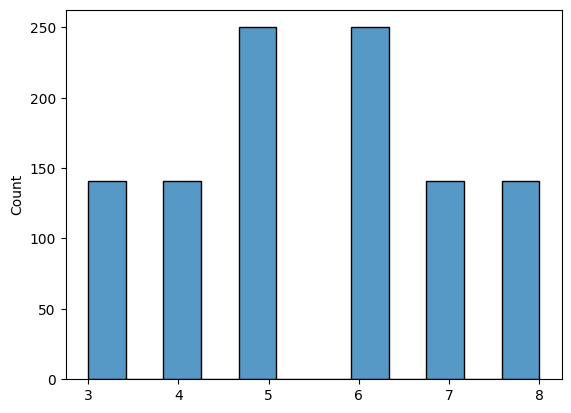

In [131]:
sns.histplot(data=Y)
df.info()

In [132]:
obj = NNclass()
obj.fit(X_train_scaled,Ytrain)
Ypredict = obj.targetpredict(X_test_scaled)
accuracy = obj.accuracy(Ypredict,Ytest)
print("Accuracy ::",accuracy)
print("------------")
precision = obj.precision(Ypredict,Ytest)
recall = obj.recall(Ypredict,Ytest)
f1score = obj.f1score(Ypredict,Ytest)
for i in precision:
  print(i,precision[i])
print("------------")
for i in recall:
  print(i,recall[i])
print("------------")
for i in f1score:
  print(i,f1score[i])

NN archutecture :: [ 7 64 32 16  8  6]
Model Trained
Last batch Loss :: 0.551142031141167
Accuracy :: 0.6995305164319249
------------
Precision class 3 1.0
Precision class 4 0.8148148148148148
Precision class 5 0.5681818181818182
Precision class 6 0.5087719298245614
Precision class 7 0.6785714285714286
Precision class 8 0.896551724137931
------------
Recall class 3 1.0
Recall class 4 0.7857142857142857
Recall class 5 0.5
Recall class 6 0.58
Recall class 7 0.6785714285714286
Recall class 8 0.896551724137931
------------
F1 Score class 3 1.0
F1 Score class 4 0.7999999999999999
F1 Score class 5 0.5319148936170213
F1 Score class 6 0.5420560747663552
F1 Score class 7 0.6785714285714286
F1 Score class 8 0.896551724137931
